# Practice 1 - CNNs: Part 1 - Custom CNNs

**Authors:** [Name 1], [Name 2]

**Date:** March 2026

**Description:** In this notebook we develop several custom convolutional neural network (CNN) models to solve the classification problem posed by the STL-10 dataset.

---
## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Dataset Loading & Exploration](#2-dataset-loading--exploration)
3. [Data Preprocessing](#3-data-preprocessing)
4. [Data Augmentation](#4-data-augmentation)
5. [Baseline CNN Model](#5-baseline-cnn-model)
6. [Improved CNN Model](#6-improved-cnn-model)
7. [Advanced Architecture: Residual Network](#7-advanced-architecture-residual-network)
8. [Advanced Architecture: Inception / Xception](#8-advanced-architecture-inception--xception)
9. [Results Comparison](#9-results-comparison)
10. [Conclusions](#10-conclusions)

---
## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import layers, Model
import os

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-03-05 15:42:58.467479: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-05 15:42:58.483220: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 15:42:58.596716: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 15:42:58.700054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772721778.792139    9102 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772721778.81

TensorFlow version: 2.18.0
Keras version: 3.7.0
GPUs available: []


2026-03-05 15:43:03.835905: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Constants
IMG_SIZE = 96        # STL-10 native resolution
NUM_CLASSES = 10
BATCH_SIZE = 32
EPOCHS = 50          # Adjust as needed
VALIDATION_SPLIT = 0.2

# Directory to save models
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

---
## 2. Dataset Loading & Exploration

The **STL-10** dataset contains:
- 5,000 labeled training images (500 per class)
- 8,000 labeled test images (800 per class)
- 100,000 unlabeled images (not used here)
- Image size: 96×96 pixels, 3 color channels (RGB)
- 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck

In [3]:
# Load STL-10 from TensorFlow Datasets
(ds_train, ds_test), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

print(ds_info)

2026-03-05 15:44:19.980908: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


/home/patricia/anaconda3/envs/dl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 0 url [00:00, ? url/s]
Dl Completed...: 100%|██████████| 1/1 [16:39<00:00, 965.56s/ url]

Dl Completed...: 100%|██████████| 1/1 [16:39<00:00, 999.09s/ url]


Dataset stl10 downloaded and prepared to /home/patricia/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='stl10',
    full_name='stl10/1.0.0',
    description="""
    The STL-10 dataset is an image recognition dataset for developing unsupervised
    feature learning, deep learning, self-taught learning algorithms. It is inspired
    by the CIFAR-10 dataset but with some modifications. In particular, each class
    has fewer labeled training examples than in CIFAR-10, but a very large set of
    unlabeled examples is provided to learn image models prior to supervised
    training. The primary challenge is to make use of the unlabeled data (which
    comes from a similar but different distribution from the labeled data) to build
    a useful prior. All images were acquired from labeled examples on ImageNet.
    """,
    homepage='http://ai.stanford.edu/~acoates/stl10/',
    data_dir=PosixGPath('/tmp/tmp00f_f4uhtfds'),
    file_format

In [4]:
# Class names
class_names = ds_info.features['label'].names
print(f"Classes: {class_names}")
print(f"Number of training samples: {ds_info.splits['train'].num_examples}")
print(f"Number of test samples: {ds_info.splits['test'].num_examples}")

Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Number of training samples: 5000
Number of test samples: 8000


2026-03-05 16:07:43.750814: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
2026-03-05 16:07:43.833691: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


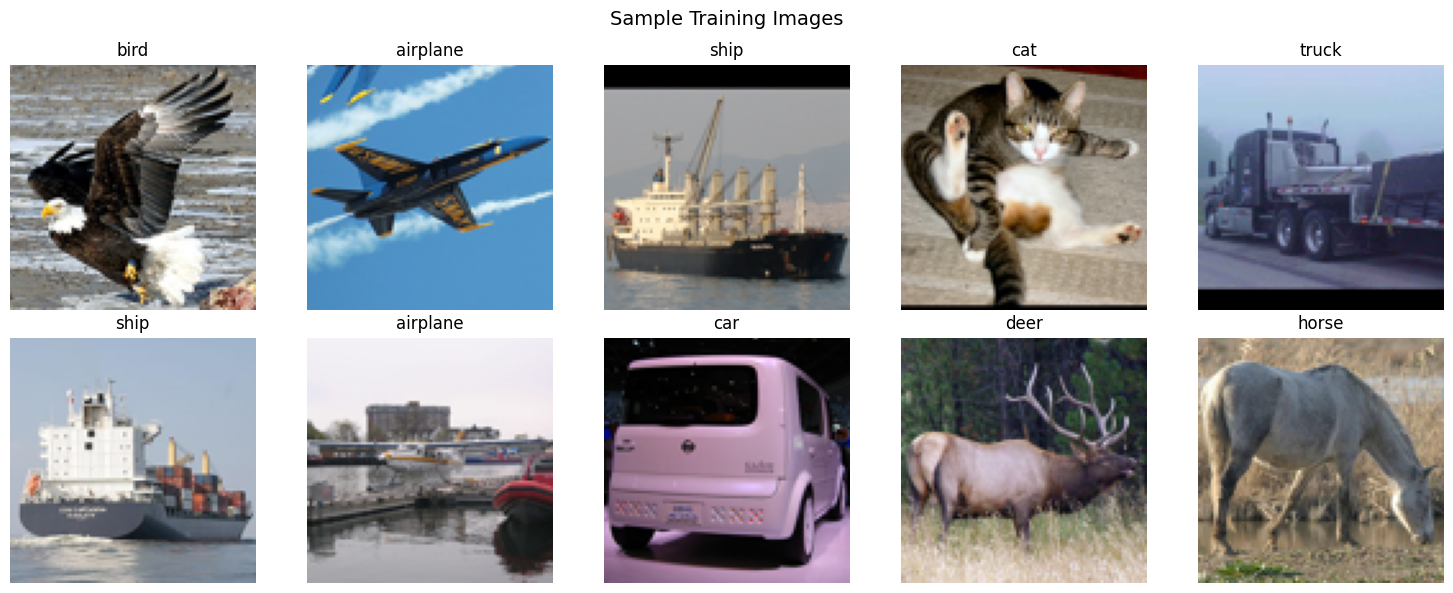

In [5]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, (image, label) in enumerate(ds_train.take(10)):
    ax = axes[i // 5, i % 5]
    ax.imshow(image.numpy())
    ax.set_title(class_names[label.numpy()])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

2026-03-05 16:08:14.372637: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


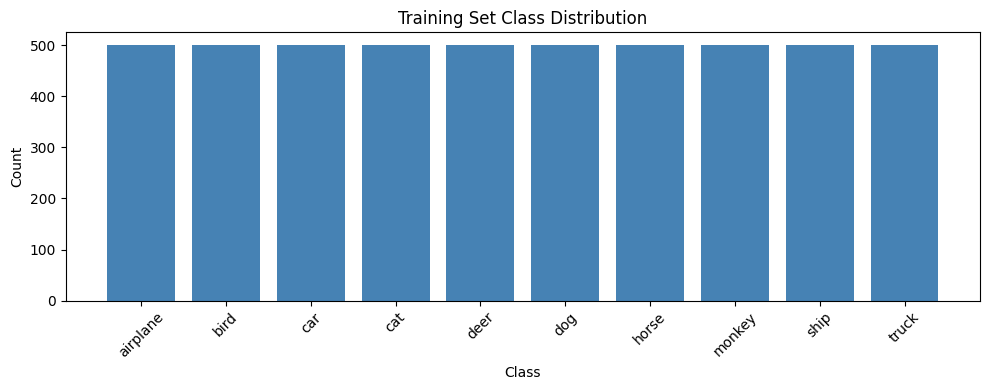

In [6]:
# Check class distribution
train_labels = [label.numpy() for _, label in ds_train]
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([class_names[u] for u in unique], counts, color='steelblue')
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 3. Data Preprocessing

Steps:
- Normalize pixel values to [0, 1]
- Resize images if needed (STL-10 is already 96×96)
- Create a validation split from the training set
- Build efficient `tf.data` pipelines with prefetching

In [7]:
def preprocess(image, label):
    """Normalize images to [0, 1] and resize."""
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, label

In [8]:
# Total training samples
num_train = ds_info.splits['train'].num_examples
num_val = int(num_train * VALIDATION_SPLIT)
num_train_actual = num_train - num_val

print(f"Training samples: {num_train_actual}")
print(f"Validation samples: {num_val}")

# Shuffle and split into train/validation
ds_train_shuffled = ds_train.shuffle(num_train, seed=SEED)

ds_val = ds_train_shuffled.take(num_val)
ds_train_split = ds_train_shuffled.skip(num_val)

# Apply preprocessing and batching
train_dataset = (
    ds_train_split
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(num_train_actual)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    ds_val
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

Training samples: 4000
Validation samples: 1000


In [9]:
# Verify shapes
for images, labels in train_dataset.take(1):
    print(f"Batch images shape: {images.shape}")
    print(f"Batch labels shape: {labels.shape}")
    print(f"Pixel value range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Batch images shape: (32, 96, 96, 3)
Batch labels shape: (32,)
Pixel value range: [0.00, 1.00]


---
## 4. Data Augmentation

To combat overfitting (especially with only ~4,000 training samples), we define data augmentation layers that will be embedded in the model and only active during training.

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

2026-03-05 16:08:56.527297: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


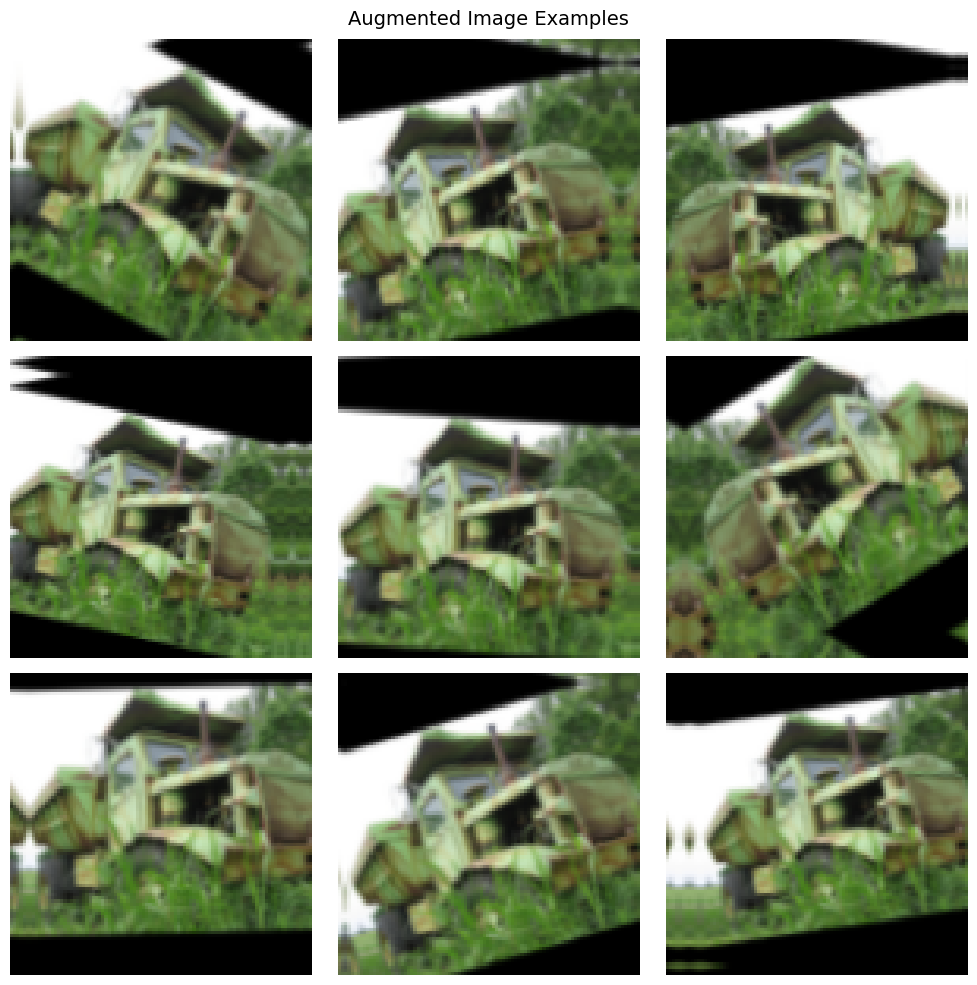

In [11]:
# Visualize augmented images
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy())
        plt.axis('off')
plt.suptitle('Augmented Image Examples', fontsize=14)
plt.tight_layout()
plt.show()

---
## Helper Functions

Utility functions for training, evaluation, and plotting that will be reused across models.

In [12]:
def plot_history(history, title=""):
    """Plot training and validation accuracy and loss curves."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
    ax1.plot(epochs_range, val_acc, 'r--o', label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, loss, 'b-o', label='Training Loss')
    ax2.plot(epochs_range, val_loss, 'r--o', label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [13]:
def train_and_evaluate(model, model_name, train_ds, val_ds, test_ds, epochs=EPOCHS):
    """Train a model, plot history, evaluate on test set, and return results."""
    
    filepath = os.path.join(MODEL_DIR, f"{model_name}.keras")
    
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            filepath=filepath,
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=callbacks
    )

    # Plot training curves
    plot_history(history, title=model_name)

    # Evaluate on test set
    best_model = keras.models.load_model(filepath)
    test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
    print(f"\n{model_name} - Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

    return {
        'model_name': model_name,
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    }

In [14]:
# Store results for comparison
results = []

---
## 5. Baseline CNN Model

A simple VGG-style architecture with stacked Conv2D + MaxPooling2D blocks. This serves as our baseline to benchmark improvements.

**Architecture:**
- 3 convolutional blocks (Conv2D → MaxPooling2D)
- Flatten → Dense → Output
- No data augmentation, no regularization

### NOTE: Determine the best architecture of the model (convolutional layers, pooling layers, number of filters, size of kernels, etc.).

are experiments needed?


In [ ]:
def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build a simple baseline CNN (no augmentation, no regularization)."""
    inputs = keras.Input(shape=input_shape)
    
    # Feature learning
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)
#     
# Try with one more level of Conv2D + MaxPooling and one less
    # x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    # x = layers.MaxPooling2D(2)(x)
# Add one more Conv2D to each model
    
    
    # Classification
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='baseline_cnn')
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,962 (9.36 MB)

 Trainable params: 2,453,962 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.2133 - loss: 2.1316
Epoch 1: val_loss improved from inf to 1.70868, saving model to models/baseline_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.2139 - loss: 2.1297 - val_accuracy: 0.3610 - val_loss: 1.7087 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4320 - loss: 1.4836
Epoch 2: val_loss improved from 1.70868 to 1.31245, saving model to models/baseline_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.4321 - loss: 1.4834 - val_accuracy: 0.5220 - val_loss: 1.3125 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5433 - loss: 1.2496
Epoch 3: val_loss improved from 1.31245 to 1.02263, saving model to models/baseline_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - accuracy: 0.5433 - loss: 1.2495 - val_accuracy: 0.6510 - val_loss: 1.0226 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━

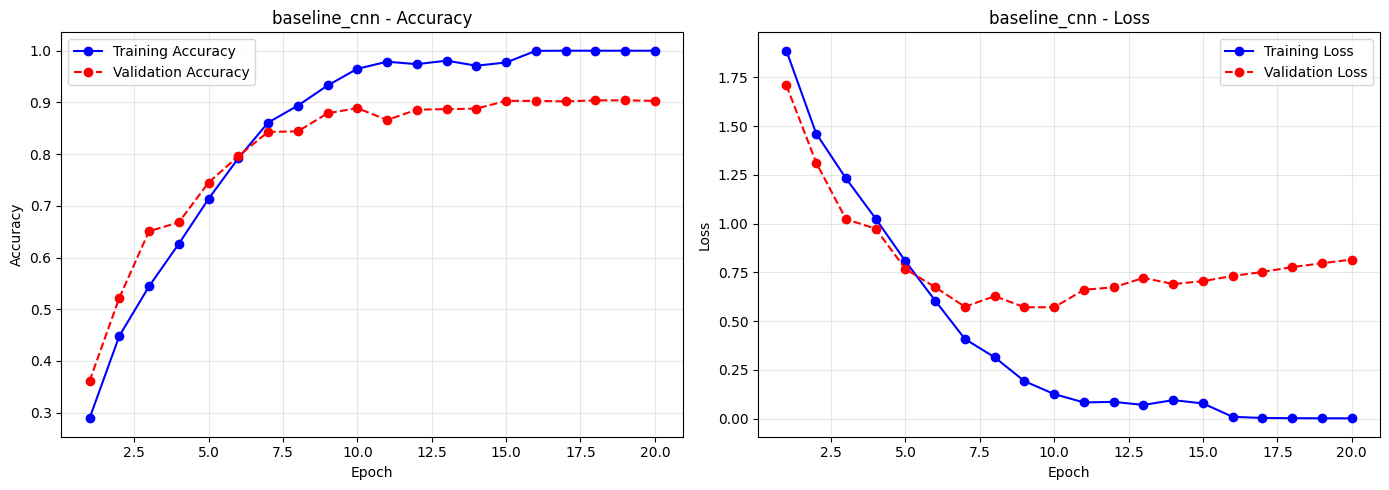

250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.5289 - loss: 2.3576

baseline_cnn - Test Accuracy: 0.5383, Test Loss: 2.2958


In [16]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_baseline = train_and_evaluate(
    baseline_model, 'baseline_cnn',
    train_dataset, val_dataset, test_dataset
)
results.append(result_baseline)

**Observations (Baseline):**

_TODO: Comment on the training curves. Is there overfitting? What accuracy did we achieve? Why is this expected given the small training set?_

---
## 6. Improved CNN Model

Improvements over the baseline:
- **Data augmentation** to increase effective training samples
- **Dropout** for regularization
- **Batch Normalization** for faster convergence
- **Deeper architecture** with more filters

In [17]:
def build_improved_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build an improved CNN with augmentation, batch norm, and dropout."""
    inputs = keras.Input(shape=input_shape)
    
    # Data augmentation (only active during training)
    x = data_augmentation(inputs)
    
    # Block 1
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Block 2
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Block 3
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Block 4
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Classification
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='improved_cnn')
    return model

improved_model = build_improved_cnn()
improved_model.summary()

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 24, 24, 128)    │             

 Total params: 3,569,834 (13.62 MB)

 Trainable params: 3,567,914 (13.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.1115 - loss: 3.4689
Epoch 1: val_loss improved from inf to 2.30298, saving model to models/improved_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 582ms/step - accuracy: 0.1115 - loss: 3.4625 - val_accuracy: 0.0870 - val_loss: 2.3030 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.1105 - loss: 2.3023
Epoch 2: val_loss improved from 2.30298 to 2.30293, saving model to models/improved_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 578ms/step - accuracy: 0.1104 - loss: 2.3023 - val_accuracy: 0.1010 - val_loss: 2.3029 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.1094 - loss: 2.3030
Epoch 3: val_loss improved from 2.30293 to 2.30251, saving model to models/improved_cnn.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 574ms/step - accuracy: 0.1094 - loss: 2.3030 - val_accuracy: 0.1010 - val_loss: 2.3025 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━

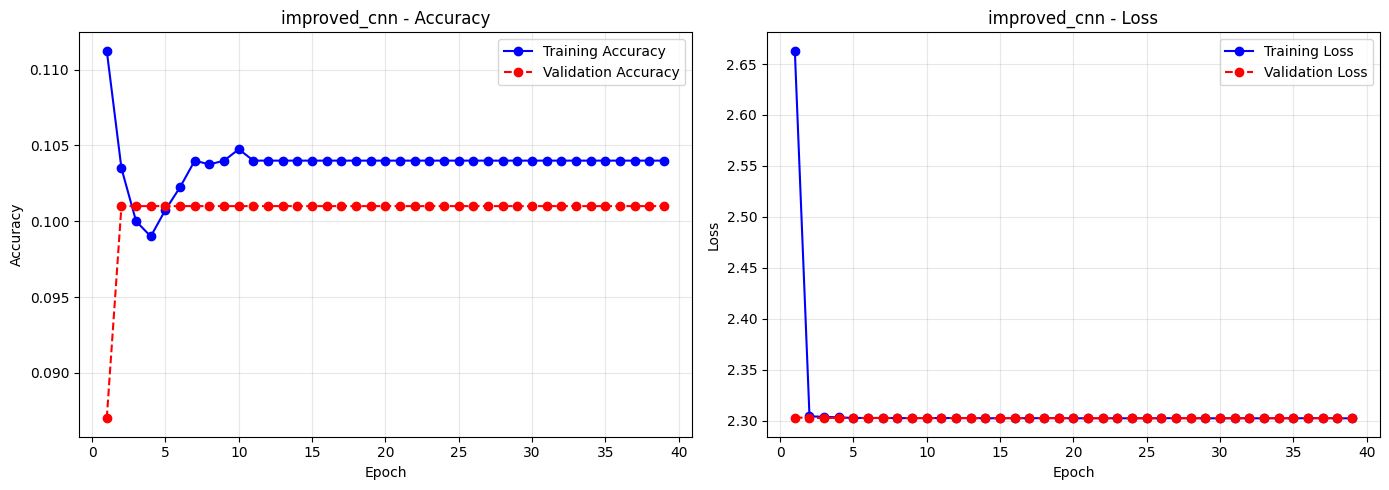

250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 152ms/step - accuracy: 0.0992 - loss: 2.3030

improved_cnn - Test Accuracy: 0.1000, Test Loss: 2.3028


In [18]:
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_improved = train_and_evaluate(
    improved_model, 'improved_cnn',
    train_dataset, val_dataset, test_dataset
)
results.append(result_improved)

**Observations (Improved CNN):**

_TODO: Compare with the baseline. Has overfitting been reduced? Did accuracy improve? Comment on the effect of data augmentation, batch normalization, and dropout._

---
## 7. Advanced Architecture: Residual Network

We implement a custom **ResNet-style** model with skip connections. Residual connections help with training deeper networks by alleviating the vanishing gradient problem.

**Key idea:** Instead of learning $H(x)$, the network learns the residual $F(x) = H(x) - x$, so the output becomes $F(x) + x$.

In [19]:
def residual_block(x, filters, downsample=False):
    """A residual block with optional downsampling."""
    strides = 2 if downsample else 1
    shortcut = x
    
    # Main path
    x = layers.Conv2D(filters, 3, strides=strides, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Shortcut path: adjust dimensions if needed
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Add shortcut
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [20]:
def build_custom_resnet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build a custom ResNet-style model."""
    inputs = keras.Input(shape=input_shape)
    
    # Data augmentation
    x = data_augmentation(inputs)
    
    # Initial convolution
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Residual blocks
    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)
    x = residual_block(x, 256, downsample=True)
    x = residual_block(x, 256)
    
    # Global Average Pooling (replaces Flatten + Dense)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='custom_resnet')
    return model

resnet_model = build_custom_resnet()
resnet_model.summary()

Model: "custom_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 96, 96, 3) │          0 │ input_layer_3[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 96, 96,    │        896 │ data_augmentatio… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 96, 96,    │      9,248 │ activation_8[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 96, 96,    │      9,248 │ activation_9[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_8[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 96, 96,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 48, 48,    │     18,496 │ activation_10[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 48, 48,    │     36,928 │ activation_11[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 48, 48,    │      2,112 │ activation_10[0]

 Total params: 2,786,058 (10.63 MB)

 Trainable params: 2,781,386 (10.61 MB)

 Non-trainable params: 4,672 (18.25 KB)

In [21]:
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_resnet = train_and_evaluate(
    resnet_model, 'custom_resnet',
    train_dataset, val_dataset, test_dataset
)
results.append(result_resnet)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1936 - loss: 2.5473
Epoch 1: val_loss improved from inf to 2.53214, saving model to models/custom_resnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.1939 - loss: 2.5449 - val_accuracy: 0.1580 - val_loss: 2.5321 - learning_rate: 0.0010
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2969 - loss: 1.8922
Epoch 2: val_loss did not improve from 2.53214
125/125 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.2969 - loss: 1.8922 - val_accuracy: 0.0910 - val_loss: 2.9406 - learning_rate: 0.0010
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3246 - loss: 1.7871
Epoch 3: val_loss improved from 2.53214 to 2.50240, saving model to models/custom_resnet.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 378s 3s/step - accuracy: 0.3246 - loss: 1.7870 - val_accuracy: 0.1500 - val_loss: 2.5024 - learning_rate: 0.0010
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3410 - loss: 1.7233
E

KeyboardInterrupt: 

**Observations (Custom ResNet):**

_TODO: Comment on how residual connections affect training. Did the deeper network train well? Compare with previous models._

---
## 8. Advanced Architecture: Inception / Xception

We implement a custom model inspired by **Inception** / **Xception** architectures:
- **Inception module:** Applies multiple filter sizes (1×1, 3×3, 5×5) in parallel and concatenates the outputs.
- **Depthwise separable convolutions** (Xception-style): More parameter-efficient than standard convolutions.

In [ ]:
def inception_module(x, filters_1x1, filters_3x3, filters_5x5):
    """A simplified Inception module with parallel convolutions."""
    # 1x1 branch
    branch_1x1 = layers.Conv2D(filters_1x1, 1, padding='same', activation='relu')(x)
    
    # 3x3 branch
    branch_3x3 = layers.Conv2D(filters_3x3, 3, padding='same', activation='relu')(x)
    
    # 5x5 branch
    branch_5x5 = layers.Conv2D(filters_5x5, 5, padding='same', activation='relu')(x)
    
    # Max pooling branch
    branch_pool = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    branch_pool = layers.Conv2D(filters_1x1, 1, padding='same', activation='relu')(branch_pool)
    
    # Concatenate
    output = layers.Concatenate()([branch_1x1, branch_3x3, branch_5x5, branch_pool])
    return output

In [ ]:
def build_custom_inception(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Build a custom Inception-style model."""
    inputs = keras.Input(shape=input_shape)
    
    # Data augmentation
    x = data_augmentation(inputs)
    
    # Initial convolution
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    # Inception modules
    x = inception_module(x, 32, 48, 16)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = inception_module(x, 64, 96, 32)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    
    x = inception_module(x, 128, 192, 64)
    x = layers.BatchNormalization()(x)
    
    # Classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='custom_inception')
    return model

inception_model = build_custom_inception()
inception_model.summary()

In [ ]:
inception_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

result_inception = train_and_evaluate(
    inception_model, 'custom_inception',
    train_dataset, val_dataset, test_dataset
)
results.append(result_inception)

**Observations (Custom Inception):**

_TODO: Comment on the multi-scale feature extraction. How does this compare with the ResNet and improved CNN? Discuss parameter efficiency._

---
## 9. Results Comparison

Summary of all custom CNN models trained.

In [ ]:
import pandas as pd

# Build comparison table
comparison_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Test Accuracy': f"{r['test_accuracy']:.4f}",
        'Test Loss': f"{r['test_loss']:.4f}"
    }
    for r in results
])

print("\n" + "="*60)
print("RESULTS SUMMARY - Custom CNNs")
print("="*60)
display(comparison_df)

In [ ]:
# Bar chart comparison
model_names = [r['model_name'] for r in results]
test_accs = [r['test_accuracy'] for r in results]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, test_accs, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.ylabel('Test Accuracy')
plt.title('Custom CNN Models - Test Accuracy Comparison')
plt.ylim(0, 1)
for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Conclusions

_TODO: Write a comprehensive comparison of all custom CNN models:_

- _Which model achieved the best accuracy and why?_
- _How did regularization techniques (data augmentation, dropout, batch normalization) affect the results?_
- _What are the advantages and disadvantages of each architecture (simple CNN vs ResNet vs Inception)?_
- _What are the main challenges when working with a small dataset like STL-10?_
- _What improvements could be made in future iterations?_